In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import duckdb
import dill

warnings.filterwarnings("ignore")

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR
from src.analysis.metrics import EVENT_COLS
from src.analysis.passing.passing import (
    PASS_ANALYSIS_COLS,
    buildup_shape_table,
    early_buildup_sequence_table,
    extract_lineup_snapshots,
    first_pass_direction_table,
    first_pass_table,
    player_network_involvement,
    pressure_escape_table,
    starting_lineup_table,
    top_pass_connections,
)
from src.analysis.possession.compare import (
    build_event_style_table,
    build_passing_style_table,
)
from src.analysis.possession.viz import (
    plot_buildup_width_depth,
    plot_first_pass_direction,
    plot_first_pass_recipient_roles,
    plot_midfield_bypass_rates,
    plot_pass_angle_rose,
    plot_pass_count_distribution,
    plot_pass_height_comparison,
    plot_pass_length_histograms,
    plot_pass_network_heatmap,
    plot_pass_vs_carry_progression,
    plot_pressure_progression_split,
)
from src.analysis.passing.structure import (
    build_zone_pass_geometry,
    build_zone_transitions,
    build_zone_exit_timing,
    summarize_zone_exit,
    build_pitch_network,
    compute_betweenness_centrality,
)
from src.analysis.passing.viz import (
    plot_zone_pass_geometry,
    plot_zone_direction_heatmap,
    plot_zone_transition_heatmap,
    plot_zone_exit_timing,
    plot_zone_exit_speed,
    plot_pitch_network,
    plot_betweenness_centrality,
    plot_betweenness_vs_involvement,
    plot_buildup_shape_arrows,
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MATCH_ID = 3749493
TEAMS = ["Arsenal", "Everton"]

In [3]:
from IPython.display import display

events_path = PROCESSED_DIR / "events_2004.parquet"
match_cols = sorted(set(EVENT_COLS + PASS_ANALYSIS_COLS))
match_df = pd.read_parquet(events_path, columns=match_cols)
match_df = match_df[match_df["match_id"] == MATCH_ID].copy()

match_info = (
    pd.read_csv(PROCESSED_DIR / "matches_2004.csv")
    .loc[lambda d: d["match_id"] == MATCH_ID]
    .iloc[0]
)
print(
    f"{match_info['match_home_team']} {match_info['match_score']} "
    f"{match_info['match_away_team']} — {match_info['match_kickoff']}"
)
print(f"Events: {len(match_df):,}")

# Build tables used throughout this notebook
passing_style = build_passing_style_table(match_df, TEAMS)
passing_style.to_csv(PROCESSED_DIR / "passing_style.csv", index=False)
duckdb.register("passing_style", passing_style)

zone_geometry   = build_zone_pass_geometry(match_df, TEAMS)
zone_transitions = build_zone_transitions(match_df, TEAMS)
zone_exit       = build_zone_exit_timing(match_df, TEAMS)
zone_exit_summary = summarize_zone_exit(zone_exit)

Arsenal 2 - 1 Everton — 2003-08-16 13:00:00.000
Events: 3,057


# Two 4-4-2s, two different games?
## A passing-structure case study — Arsenal 2–1 Everton (16 Aug 2003)

### Abstract

Two sides can field the same nominal formation and still play fundamentally different football. Using StatsBomb event data from a single Premier League fixture, this notebook tests whether Arsenal and Everton — both lined up in a 4-4-2 — express two distinct passing identities. We profile each team across five structural dimensions (passing geometry, build-up, network structure, behaviour under pressure, and progression mechanism) and ask, at each step, whether the metrics support or undermine a specific stylistic hypothesis.

### Hypothesis

> **H1 — Arsenal play a more controlled, tactical game** (favouring carries and shorter passes, retaining the ball, and progressing gradually toward the opposition half), **while Everton play a faster, more direct game** (favouring long balls, quick vertical transitions, and a more "rushed" route up the pitch).

We treat H1 as a set of testable predictions, one per section:

| Section | Metric family | If H1 holds, we expect… |
|---|---|---|
| **1 Geometry** | length, verticality, direction, circulation | Arsenal: shorter, more measured circulation. Everton: longer passes. |
| **2 Build-up** | first pass, zone-exit timing | Arsenal: slower, retained build-up from the back. Everton: faster, more direct defensive-third exits. |
| **3 Networks** | connectivity, clustering, betweenness | Arsenal: denser, more evenly connected structure. Everton: sparser, more bridge-dependent. |
| **4 Pressure** | completion & forward distance under pressure | Arsenal: shorten up and retain. Everton: go longer / more vertical to escape. |
| **5 Progression** | pass vs carry share, per-action gain | Arsenal: relatively more carry-led. Everton: long-ball-led, larger per-pass gains. |

Each section below states its prediction, presents the metrics, and closes with a **verdict** on that prediction. Section 6 synthesises the evidence into an overall judgement on H1.

### Data & scope

Single match (`match_id = 3749493`), Regular Play events only unless otherwise noted. Possession-chain metrics (duration, directness, pressure rate) are analysed separately in `possession.ipynb`. A one-game sample is a **case study, not proof**: it can illustrate and support H1 for this fixture but cannot establish a season-long tendency. Findings should be read as "consistent with H1" rather than "confirms H1 in general." Limitations are discussed in Section 6.

<hr>

## 1. Passing geometry

**Prediction (H1).** Arsenal's passes should be *shorter* and their circulation more measured; Everton's passes should be *longer*. We also separate two ideas that are easy to conflate — pass *length* and pass *direction* — and check both, since "direct" need not mean "more forward."

### Overall geometry

`verticality` measures how much passes point forward relative to their total distance.
`lateral_circulation_pct` captures sideways circulation, and `angle_entropy` measures
how varied the passing directions are.

,team,passes,verticality,forward_pass_pct,backward_pass_pct,lateral_pass_pct,lateral_circulation_pct,angle_entropy
0,Arsenal,174.0,0.37,66.09,21.84,12.07,42.53,2.82
1,Everton,150.0,0.25,59.33,29.33,11.33,51.33,2.89


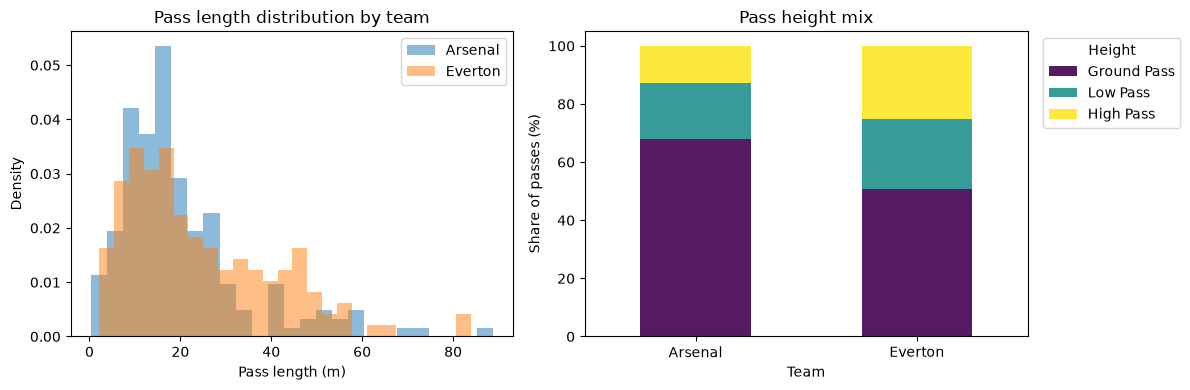

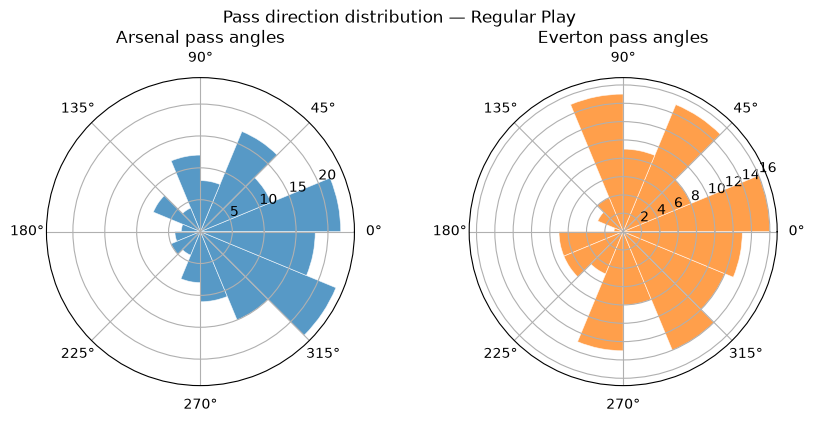

In [4]:
geometry_cols = [
    "team",
    "passes",
    "verticality",
    "forward_pass_pct",
    "backward_pass_pct",
    "lateral_pass_pct",
    "lateral_circulation_pct",
    "angle_entropy",
]

display(passing_style[geometry_cols].round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pass_length_histograms(
    match_df,
    seasons=None,
    teams=TEAMS,
    play_pattern="Regular Play",
    bins=25,
    ax=axes[0],
)
plot_pass_height_comparison(
    match_df[match_df["play_pattern"] == "Regular Play"],
    TEAMS,
    ax=axes[1],
)
plt.tight_layout()
plt.show()

plot_pass_angle_rose(match_df, TEAMS, play_pattern="Regular Play")
plt.show()

**Findings — overall geometry.** Arsenal played more passes (174 vs 150) at higher verticality (0.37 vs 0.25) and a higher forward share (66.1% vs 59.3%), while Everton recorded more backward passing (29.3% vs 21.8%) and higher lateral circulation (51.3% vs 42.5%). The length and height charts show Arsenal keeping the ball lower and shorter; Everton played longer, more aerial passes in more varied directions (angle entropy 2.89 vs 2.82).

**Verdict — partially supports H1.** The *length* prediction holds cleanly: Arsenal short, Everton long. But the direction data complicates a naive "Everton = direct" reading — Everton actually played *fewer* forward and *more* backward/lateral passes. Everton's directness is therefore expressed through pass *length*, not through a more forward-facing orientation on every pass. We return to this distinction in Sections 2 and 4.

### Zone-specific geometry

Pass direction is not uniform across the pitch. A build-from-the-back team typically
plays lateral or backward passes in the defensive third, then shifts to forward passing
once it reaches midfield. The charts below show how each team's directional mix
changes as the ball moves through each third.

,team,zone,passes,forward_pct,lateral_pct,backward_pct,avg_length,completion_pct
0,Arsenal,defensive,68,72.1,11.8,16.2,22.3,82.4
1,Arsenal,midfield,84,60.7,15.5,23.8,18.4,88.1
2,Arsenal,attacking,22,68.2,0.0,31.8,19.5,63.6
3,Everton,defensive,31,80.6,9.7,9.7,25.5,83.9
4,Everton,midfield,90,62.2,5.6,32.2,25.4,77.8
5,Everton,attacking,29,27.6,31.0,41.4,19.9,55.2


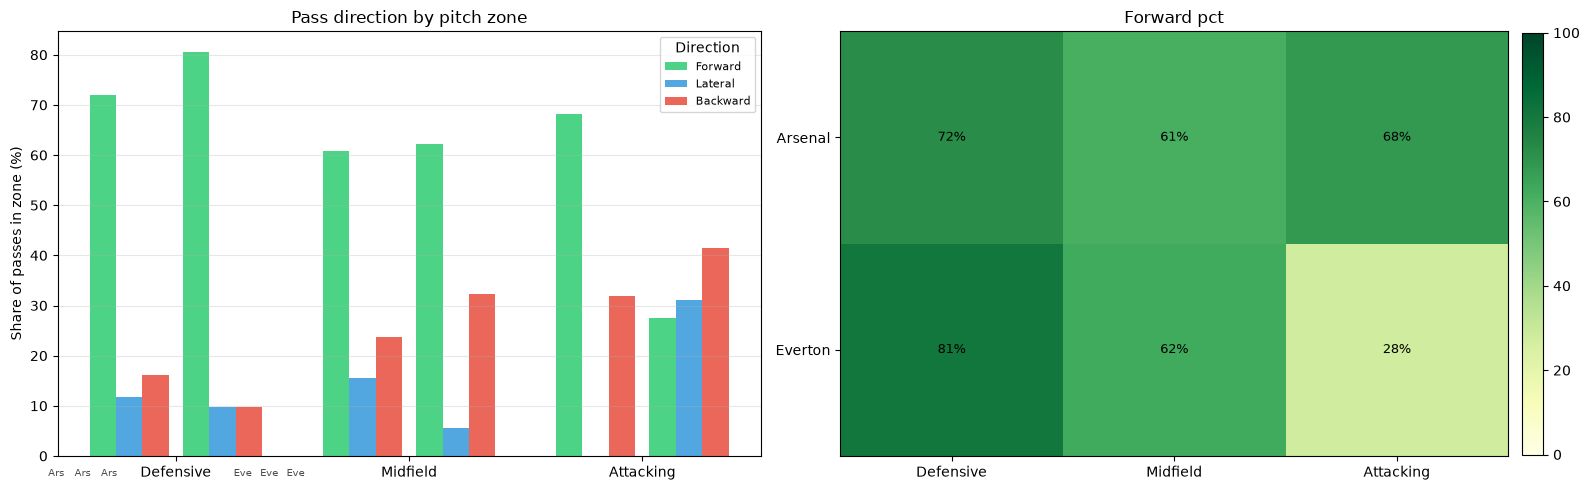

In [5]:
display_cols = ["team", "zone", "passes", "forward_pct", "lateral_pct", "backward_pct", "avg_length", "completion_pct"]
display(zone_geometry[display_cols].round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_zone_pass_geometry(zone_geometry, TEAMS, ax=axes[0])
plot_zone_direction_heatmap(zone_geometry, TEAMS, metric="forward_pct", ax=axes[1])
plt.tight_layout()
plt.show()

**Findings — zone geometry.** Across all three thirds Arsenal sustained a high forward share (defensive 72.1%, midfield 60.7%, attacking 68.2%) and played *zero* lateral passes in the attacking third — when advanced, they committed forward or recycled backward, never circulated sideways. Everton's forward share decayed as they advanced (defensive 80.6% → midfield 62.2% → attacking 27.6%), and in the final third they turned to lateral (31.0%) and backward (41.4%) passing at low completion (55.2%). Everton's passes were also consistently longer (defensive third 25.5 vs 22.3 yards).

**Verdict — supports H1, with a twist.** Everton committed forward most readily *deep* — the long ball out of defense — but stalled once advanced, consistent with a side that arrives quickly yet lacks controlled circulation to finish moves. Arsenal's even, forward-but-shorter profile fits the "measured but purposeful" build.

### Zone-to-zone transitions

A completed pass from the defensive third landing in the attacking third skips midfield
entirely. A step-by-step team shows high counts on the adjacent-diagonal cells
(defensive → midfield, midfield → attacking).

- **Diagonal** (def→def, mid→mid, att→att): circulation within the same zone.
- **One step off diagonal** (def→mid, mid→att): incremental progression.
- **Two steps off diagonal** (def→att): zone-skipping direct ball.
- **Backward cells** (mid→def, att→mid): possession recycled under pressure.


Arsenal:


to_zone,defensive,midfield,attacking
from_zone,,,
defensive,22.9,15.3,0.7
midfield,3.5,40.3,7.6
attacking,0.0,1.4,8.3



Everton:


to_zone,defensive,midfield,attacking
from_zone,,,
defensive,12.5,9.8,0.9
midfield,4.5,44.6,13.4
attacking,0.0,3.6,10.7


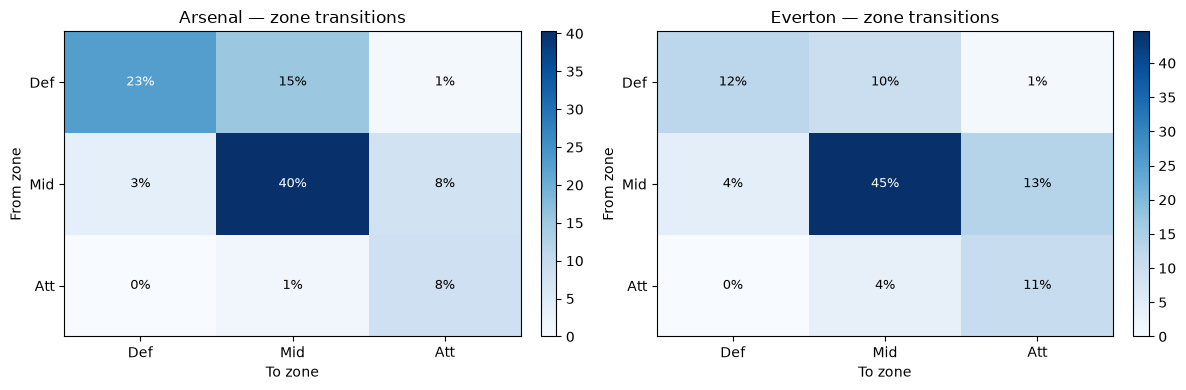

In [6]:
for team in TEAMS:
    print(f"\n{team}:")
    td = zone_transitions[zone_transitions["team"] == team]
    display(
        td.pivot_table(index="from_zone", columns="to_zone", values="pct", aggfunc="sum", fill_value=0)
        .reindex(index=["defensive", "midfield", "attacking"],
                 columns=["defensive", "midfield", "attacking"], fill_value=0)
        .round(1)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, team in zip(axes, TEAMS):
    plot_zone_transition_heatmap(zone_transitions, team, ax=ax)
plt.tight_layout()
plt.show()

**Findings — zone transitions.** The zone-to-zone matrices are broadly similar; the main visible difference is Arsenal's greater share of defensive-third recycling (def→def), i.e. circulating in their own half before progressing. Neither side relied on zone-skipping (def→att) passes.

**Verdict — weakly supports H1.** Arsenal's defensive-third circulation fits the retain-and-build picture, but the effect is modest in this single match and should not be over-read.

<hr>

## 2. Build-up and exit from defense

**Prediction (H1).** Arsenal should leave their defensive third more slowly, with more passes and more retention (patient build-up). Everton should exit faster and more directly — the long ball out of the back.

### Buildup shape and 4-4-2 structure

Both teams start from a 4-4-2, but the shape only tells us the nominal structure.
The buildup question is how each team uses that structure when a Regular Play
possession begins: who receives the first pass, whether the ball goes short or
bypasses midfield, how quickly possession creates width, and whether circulation
runs through central midfield.

In [7]:
lineup_shape = starting_lineup_table(match_df)
tactical_shapes = extract_lineup_snapshots(match_df)

lineup_shape.to_csv(PROCESSED_DIR / "lineup_shape.csv", index=False)

print("Starting formations")
display(
    lineup_shape[["team", "formation"]]
    .drop_duplicates()
    .sort_values("team")
    .reset_index(drop=True)
)

print("Starting XI by role")
display(
    lineup_shape[["team", "player", "position", "role_group"]]
    .sort_values(["team", "role_group", "position", "player"])
    .reset_index(drop=True)
)

print("Tactical shape snapshots")
display(
    tactical_shapes[["team", "event_type", "minute", "second", "formation"]]
    .drop_duplicates()
    .sort_values(["team", "minute", "second"])
    .reset_index(drop=True)
)

Starting formations


,team,formation
0,Arsenal,442
1,Everton,442


Starting XI by role


,team,player,position,role_group
0,Arsenal,Sulzeer Jeremiah ''Sol' Campbell,Left Center Back,center_back
1,Arsenal,Kolo Habib Touré,Right Center Back,center_back
2,Arsenal,Gilberto Aparecido da Silva,Left Defensive Midfield,central_midfield
3,Arsenal,Patrick Vieira,Right Defensive Midfield,central_midfield
4,Arsenal,Thierry Henry,Left Center Forward,forward
5,Arsenal,Sylvain Wiltord,Right Center Forward,forward
6,Arsenal,Ashley Cole,Left Back,fullback
7,Arsenal,Laureano Bisan-Etame Mayer,Right Back,fullback
8,Arsenal,Jens Lehmann,Goalkeeper,goalkeeper
9,Arsenal,Robert Pirès,Left Midfield,wide_midfield


Tactical shape snapshots


,team,event_type,minute,second,formation
0,Arsenal,Starting XI,0,0,442
1,Arsenal,Tactical Shift,12,52,442
2,Arsenal,Tactical Shift,30,22,442
3,Arsenal,Tactical Shift,46,17,442
4,Arsenal,Tactical Shift,70,58,442
5,Everton,Starting XI,0,0,442
6,Everton,Tactical Shift,67,8,4231


In [8]:
first_passes = first_pass_table(match_df, TEAMS)
early_sequences = early_buildup_sequence_table(match_df, TEAMS, n_passes=3)
buildup_shape = buildup_shape_table(match_df, TEAMS)

first_passes.to_csv(PROCESSED_DIR / "first_passes.csv", index=False)
early_sequences.to_csv(PROCESSED_DIR / "early_buildup_sequences.csv", index=False)
buildup_shape.to_csv(PROCESSED_DIR / "buildup_shape.csv", index=False)

# display(first_passes.head(12).round(2))

buildup_cols = [
    "team",
    "regular_play_buildups",
    "first_pass_short_pct",
    "first_pass_forward_pct",
    "first_pass_to_fullback_or_wide_pct",
    "first_pass_to_central_midfield_pct",
    "first_pass_to_forward_pct",
    "first_pass_bypass_midfield_pct",
    "defensive_to_advanced_first_pass_pct",
    "early_width_y_std",
    "early_depth_x_std",
    "early_wide_role_target_pct",
    "early_central_involvement_pct",
    "early_central_lane_pct",
    "avg_passes_to_wide_channel",
    "avg_passes_to_final_third",
]
display(buildup_shape[buildup_cols].round(2))

,team,regular_play_buildups,first_pass_short_pct,first_pass_forward_pct,first_pass_to_fullback_or_wide_pct,first_pass_to_central_midfield_pct,first_pass_to_forward_pct,first_pass_bypass_midfield_pct,defensive_to_advanced_first_pass_pct,early_width_y_std,early_depth_x_std,early_wide_role_target_pct,early_central_involvement_pct,early_central_lane_pct,avg_passes_to_wide_channel,avg_passes_to_final_third
0,Arsenal,38.0,36.84,73.68,28.95,28.95,23.68,5.26,10.53,12.48,10.24,32.98,47.87,29.79,1.16,1.75
1,Everton,35.0,42.86,65.71,22.86,31.43,20.00,8.57,8.57,12.67,15.81,29.47,48.42,36.84,1.38,1.92


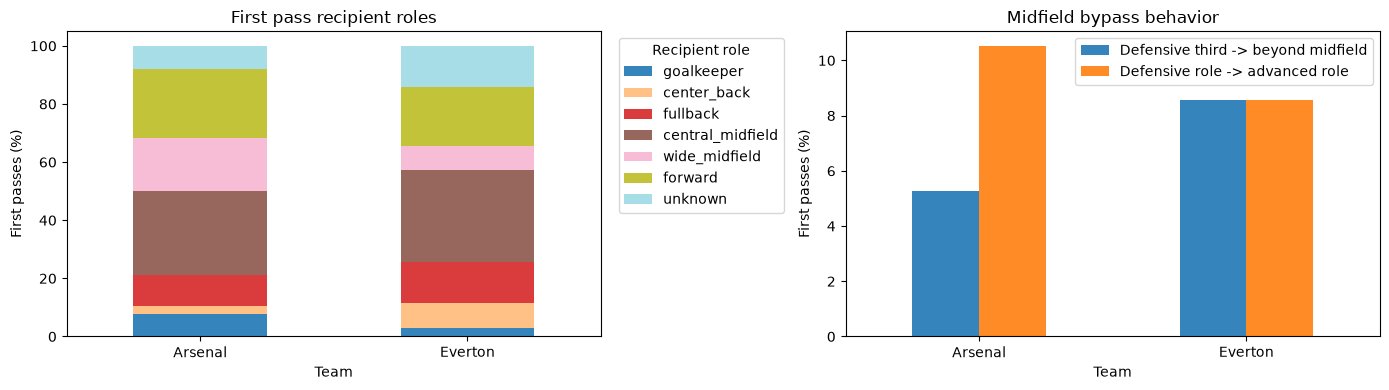

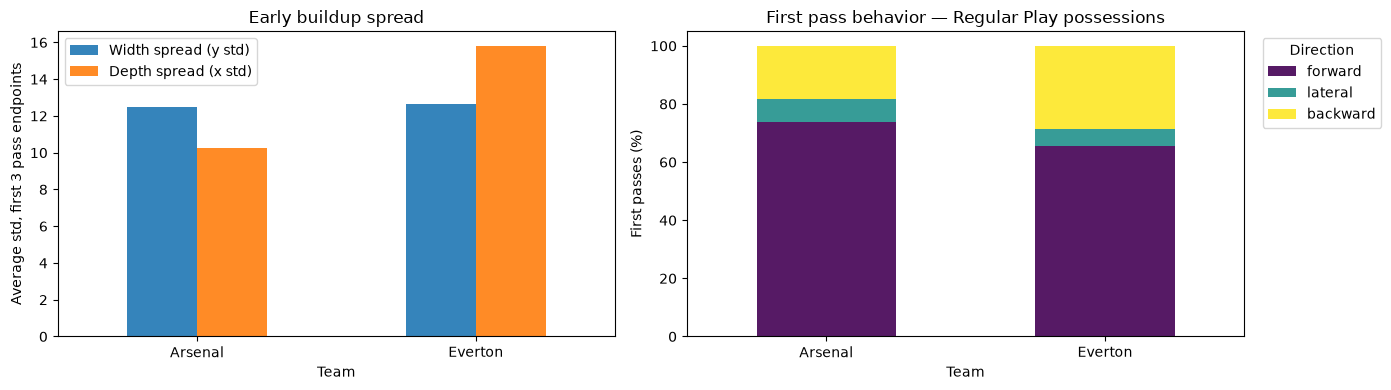

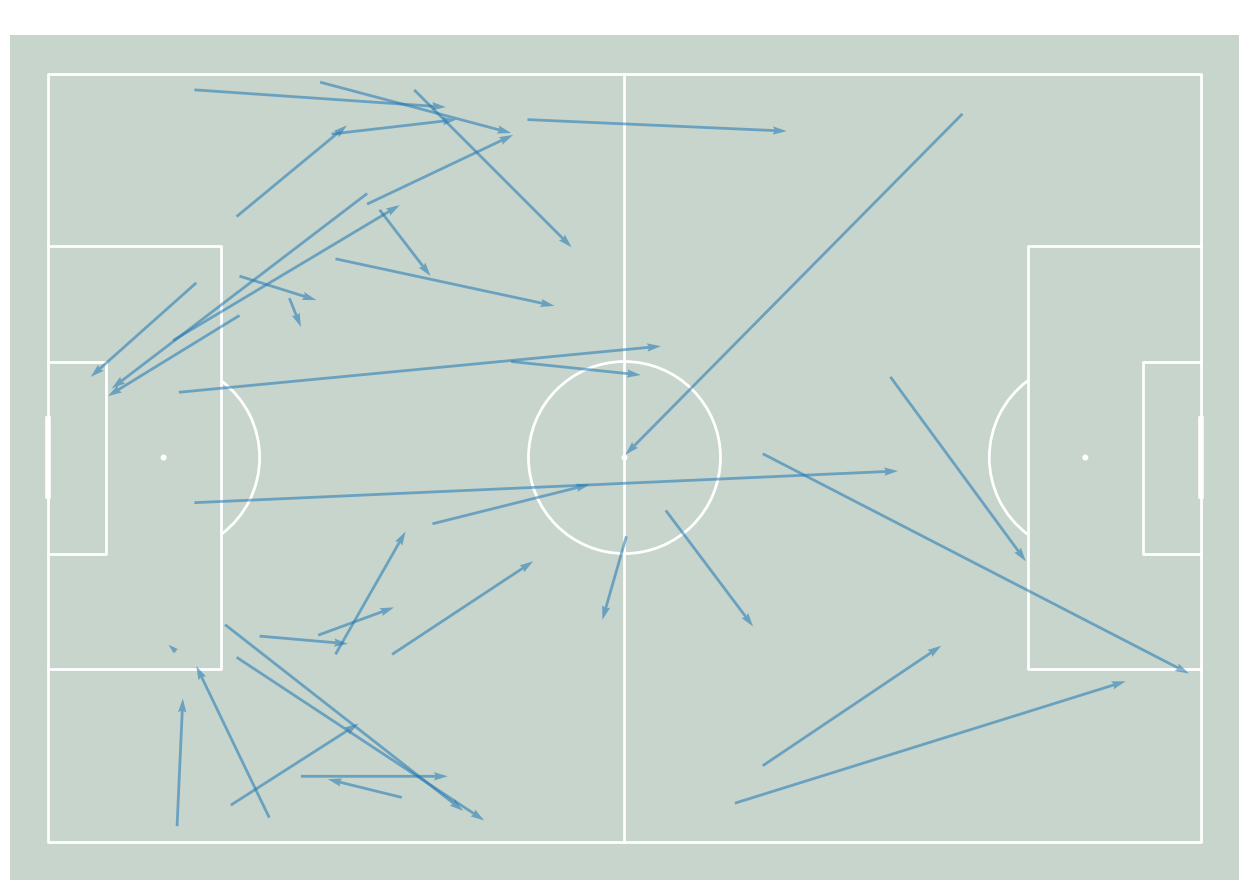

Arsenal — first 1 buildup pass(es) per possession


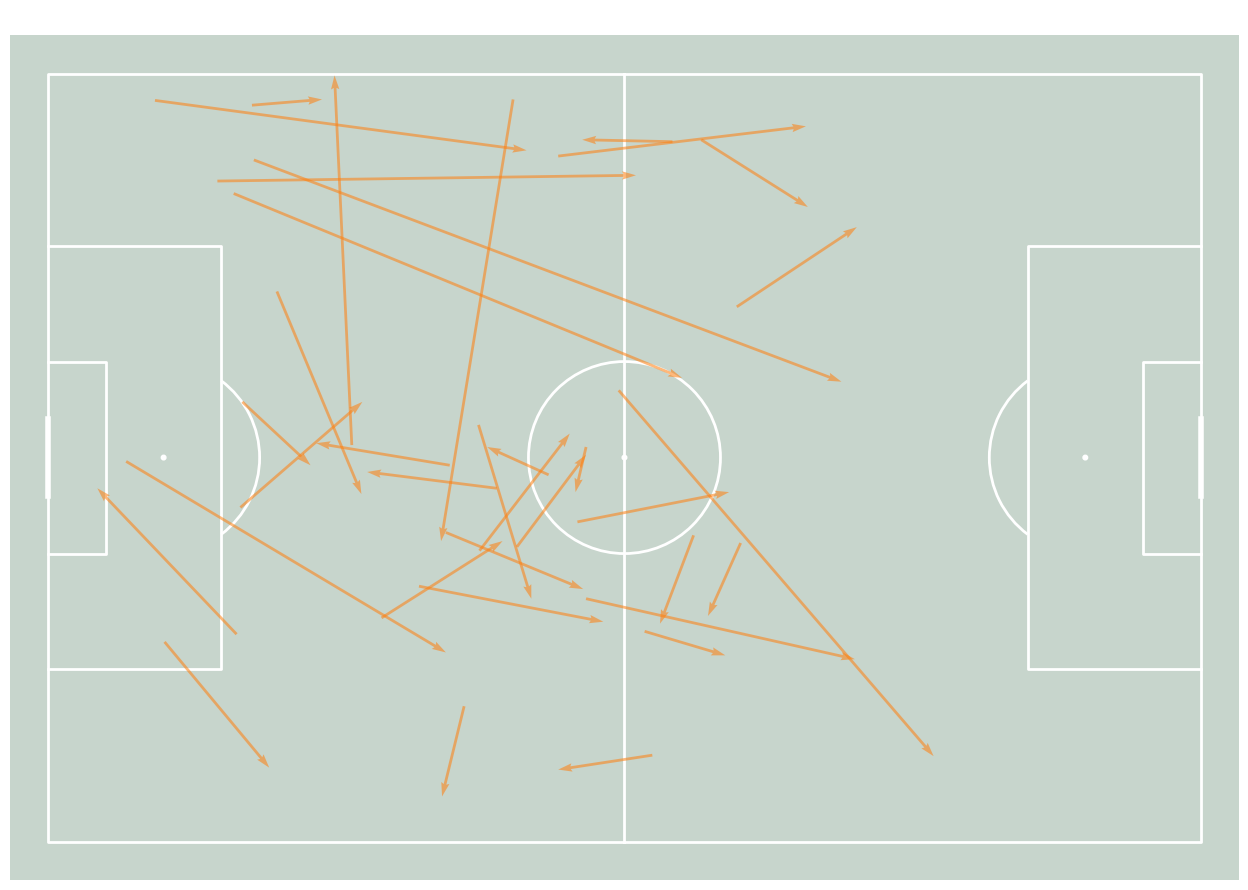

Everton — first 1 buildup pass(es) per possession


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_first_pass_recipient_roles(first_passes, ax=axes[0])
plot_midfield_bypass_rates(buildup_shape, ax=axes[1])
plt.tight_layout()
plt.show()

first_pass_directions = first_pass_direction_table(match_df, TEAMS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_buildup_width_depth(buildup_shape, ax=axes[0])
plot_first_pass_direction(first_pass_directions, ax=axes[1])
plt.tight_layout()
plt.show()

max_pass_number = 1
fig, ax = plot_buildup_shape_arrows(early_sequences, TEAMS[0], TEAMS, max_pass_number=max_pass_number)
plt.show()
print(f"{TEAMS[0]} — first {max_pass_number} buildup pass(es) per possession")

fig, ax = plot_buildup_shape_arrows(early_sequences, TEAMS[1], TEAMS, max_pass_number=max_pass_number)
plt.show()
print(f"{TEAMS[1]} — first {max_pass_number} buildup pass(es) per possession")


**Findings — build-up shape.**

- With `first_pass_short_pct` sitting at 36.84% and 42.86% for Arsenal and Everton respectively, fewer than half of all opening passes were short — indicating that both teams preferred to play with intent from the first touch rather than recycling in tight areas. The ball was moved with enough weight to stretch the opposition defensive block early in each possession.
- Despite that tendency toward longer passes, `first_pass_bypass_midfield_pct` (5.26% Arsenal, 8.57% Everton) and `defensive_to_advanced_first_pct` (10.53% Arsenal, 8.57% Everton) remain low, suggesting that direct line-skipping was not a primary mechanism for either team. Progression was still routed through midfield even when individual passes covered more ground — pointing to a structured buildup rather than a purely speculative one.
- `early_width_y_std` (12.48 Arsenal, 12.67 Everton), `early_wide_role_target_pct` (29.79% and 36.84%), and `avg_passes_to_wide_channel` (1.16 and 1.38) collectively show that both teams opened up the pitch through the wide channels early. Everton directed a slightly greater share of their early possession toward wide targets, using fullbacks and wide midfielders to pin back opposition fullbacks and open up space centrally.
- That central space was then capitalised on through the middle. `early_central_involvement_pct` (47.87% Arsenal, 48.42% Everton) and `early_central_lane_pct` (29.79% Arsenal, 36.84%) confirm that central midfielders were consistently active in the early buildup phase for both teams — functioning as the primary link between wide ball-carriers and more advanced positions.
- Although both teams lined up in a 4-4-2, their use of the shape differed in how possession was circulated. Arsenal's first-pass recipient profile leaned heavily toward forward-facing players, consistent with their higher forward pass percentage and a preference for pushing the ball upfield quickly. Everton, by contrast, distributed more frequently to fullbacks and centre-backs as first recipients, suggesting a more deliberate recycling pattern before committing forward — a tendency confirmed by their higher backward pass share on the opening action of each possession.

Conclusion: Both teams shared a structurally similar buildup framework — opening wide, connecting through central midfield, and avoiding direct bypassing of the midfield line. The divergence lay in the details of circulation and direction. Arsenal's buildup was more forward-oriented from the first touch, cycling possession through attacking-minded players and prioritising momentum. Everton's approach was marginally more patient and width-dependent, relying on their defensive line and fullbacks to retain and reset before progressing.

**Verdict — neutral on H1 at the shape level.** Build-up *shape* (width, central involvement, midfield routing) was strikingly similar for both sides, so the hypothesis is neither confirmed nor denied here. The stylistic split shows up not in *where* they build but in *how fast and how directly they leave defense* — tested next.

<hr>

### First-pass summary

This supplemental view isolates the **first pass** of each Regular Play possession
without the full lineup-shape detail above. Endpoint spread (`avg_endpoint_width_std`
and `avg_endpoint_depth_std`) gives a simple proxy for whether longer possessions
expand across width or depth.

,team,direction,count,pct
0,Arsenal,forward,28,73.68
1,Arsenal,lateral,3,7.89
2,Arsenal,backward,7,18.42
3,Everton,forward,23,65.71
4,Everton,lateral,2,5.71
5,Everton,backward,10,28.57


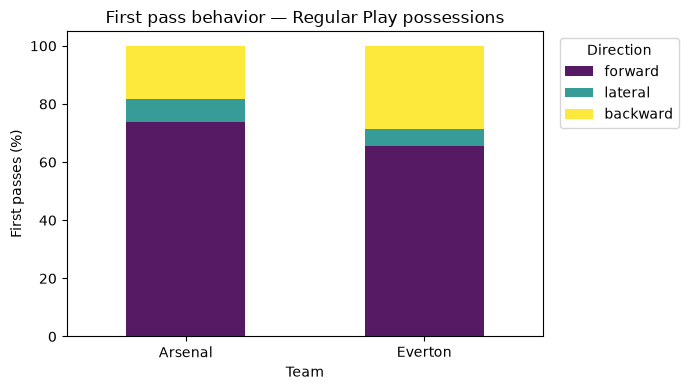

,team,first_forward_pct,first_backward_pct,first_lateral_pct,first_short_pct,first_long_pct,first_from_defensive_third_pct,first_into_midfield_or_better_pct,avg_endpoint_width_std,avg_endpoint_depth_std
0,Arsenal,73.68,18.42,7.89,36.84,63.16,73.68,57.89,15.68,18.37
1,Everton,65.71,28.57,5.71,42.86,57.14,40.00,74.29,17.20,21.20


In [10]:
first_pass = first_pass_direction_table(match_df, TEAMS)
display(first_pass.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
plot_first_pass_direction(first_pass, ax=ax)
plt.tight_layout()
plt.show()

buildup_cols = [
    "team",
    "first_forward_pct",
    "first_backward_pct",
    "first_lateral_pct",
    "first_short_pct",
    "first_long_pct",
    "first_from_defensive_third_pct",
    "first_into_midfield_or_better_pct",
    "avg_endpoint_width_std",
    "avg_endpoint_depth_std",
]
display(passing_style[buildup_cols].round(2))

<hr>

### Zone exit timing

For Regular Play possessions that **start inside the defensive third** (x < 40),
how many passes and how many seconds elapse before the ball exits to midfield?

- **`direct_exits_pct`**: share of possessions where the first action out of the
  defensive third exits immediately — a long ball or instant carry forward.
- **`median_passes_before_exit`**: typical circulation depth before committing forward.
- A team with low `direct_exits_pct` but short `median_seconds_before_exit`
  exits quickly after 1–2 short passes — structured but efficient buildup.

Zone exit summary (Regular Play, possessions starting in defensive third):


,team,def_third_possessions,exit_rate_pct,median_passes_before_exit,median_seconds_before_exit,mean_passes_before_exit,direct_exits_pct
0,Arsenal,30,83.33,0.0,3.0,0.88,56.00
1,Everton,13,100.00,0.0,4.0,0.38,76.92


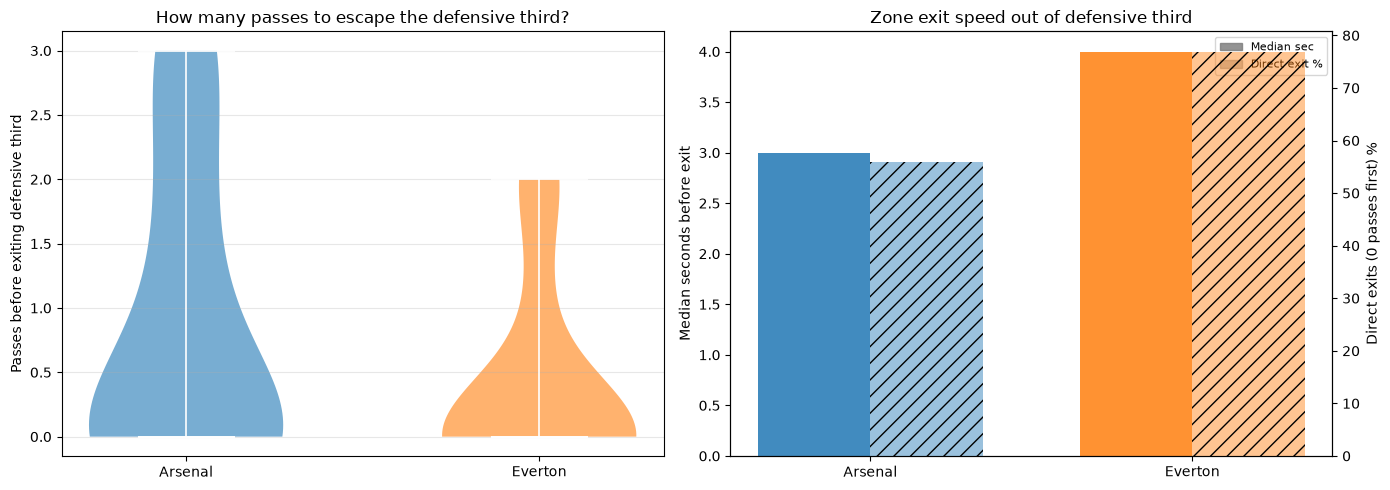

In [11]:
summary_cols = [
    "team", "def_third_possessions", "exit_rate_pct",
    "median_passes_before_exit", "median_seconds_before_exit",
    "mean_passes_before_exit", "direct_exits_pct",
]
print("Zone exit summary (Regular Play, possessions starting in defensive third):")
display(zone_exit_summary[summary_cols].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_zone_exit_timing(zone_exit, TEAMS, ax=axes[0])
plot_zone_exit_speed(zone_exit, TEAMS, ax=axes[1])
plt.tight_layout()
plt.show()

**Findings — zone-exit timing.** Of possessions starting in the defensive third, Everton exited to midfield on *every* one (100% exit rate) and did so directly 76.9% of the time — a long ball or instant carry rather than a build-up. Arsenal exited less often (83.3%) and far less directly (56.0% direct exits), more frequently choosing to retain and recycle in their own half before committing forward. Arsenal also took slightly longer over the average build-up (median 3.0s but with more measured circulation), while Everton's exits were quick and decisive.

**Verdict — supports H1.** This is among the clearest evidence for the hypothesis: Everton rush out of defense via the direct ball, whereas Arsenal build into the opposition half more patiently. (Caveat: Everton had only 13 such possessions to Arsenal's 30, so the 100% figure is fragile.)

<hr>

## 3. Network structure

**Prediction (H1).** A controlled, tactical side should produce a *denser, more evenly connected* passing network — more links used, more local triangles, no single point of failure. A more direct side should look *sparser* and lean more on a few bridge players to hold the structure together.

### Network metrics

The pass network uses completed Regular Play passes and `pass_recipient`.
`centralization` rises when a small number of players dominate involvement,
`connectivity` measures how many possible player-to-player links were used,
and `clustering` measures whether connected players formed local triangles.

,team,network_players,centralization,connectivity,clustering
0,Arsenal,13,0.088,0.449,0.747
1,Everton,14,0.089,0.341,0.625


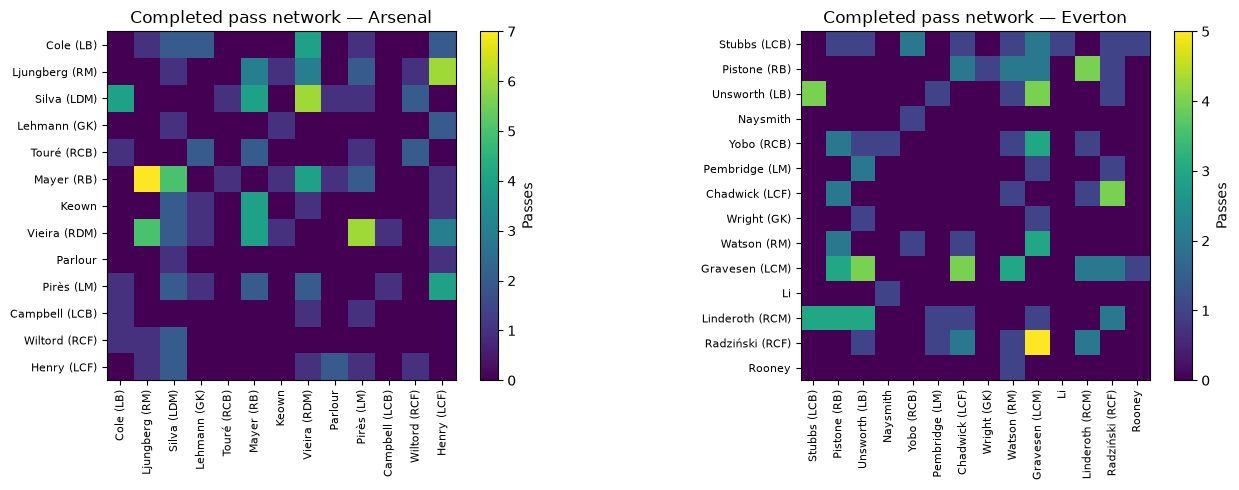

In [12]:
network_cols = ["team", "network_players", "centralization", "connectivity", "clustering"]
display(passing_style[network_cols].round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, team in zip(axes, TEAMS):
    plot_pass_network_heatmap(match_df, team, ax=ax)
plt.tight_layout()
plt.show()

<hr>

### Network dependency

The network metrics above show overall structure. These tables ask a more specific question: was the team’s passing structure distributed across many players, or did it depend on one hub or one repeated connection?

- `top_player_involvement_pct`: **degree-based** — the busiest player's share of all distinct passing connections, counting the teammates they distribute to and receive from. It reflects breadth of links, not raw pass volume.
- `top_edge_pct`: share of completed Regular Play network passes through the most common passer-recipient connection.

Higher values suggest a more centralized or player-dependent structure; lower values suggest the passing load was more evenly shared.

In [13]:
dependency_cols = [
    "team",
    "centralization",
    "connectivity",
    "clustering",
    "top_player_name",
    "top_player_involvement_pct",
    "top_edge",
    "top_edge_pct",
]
display(passing_style[dependency_cols].round(2))

regular_play_passes = match_df[
    (match_df["type"] == "Pass") & (match_df["play_pattern"] == "Regular Play")
].copy()

player_involvement = player_network_involvement(regular_play_passes, TEAMS, top_n=6)
top_connections = top_pass_connections(regular_play_passes, TEAMS, top_n=6)

print("Top player involvement")
display(player_involvement.round({"involvement_pct": 2}))

print("Top pass connections")
display(top_connections.round({"edge_pct": 2}))

,team,centralization,connectivity,clustering,top_player_name,top_player_involvement_pct,top_edge,top_edge_pct
0,Arsenal,0.09,0.45,0.75,Gilberto Aparecido da Silva,12.14,Laureano Bisan-Etame Mayer -> Fredrik Ljungberg,4.86
1,Everton,0.09,0.34,0.62,Thomas Gravesen,12.90,Tomasz Radziński -> Thomas Gravesen,4.46


Top player involvement


,team,rank,player,involvements,involvement_pct
0,Arsenal,1,Gilberto Aparecido da Silva,17,12.14
1,Arsenal,2,Patrick Vieira,16,11.43
2,Arsenal,3,Robert Pirès,15,10.71
3,Arsenal,4,Laureano Bisan-Etame Mayer,14,10.00
4,Arsenal,5,Thierry Henry,14,10.00
5,Arsenal,6,Fredrik Ljungberg,12,8.57
6,Everton,1,Thomas Gravesen,16,12.90
7,Everton,2,Tomasz Radziński,13,10.48
8,Everton,3,Alessandro Pistone,12,9.68
9,Everton,4,David Unsworth,12,9.68


Top pass connections


,team,rank,player,pass_recipient,edge,weight,edge_pct
0,Arsenal,1,Laureano Bisan-Etame Mayer,Fredrik Ljungberg,Laureano Bisan-Etame Mayer -> Fredrik Ljungberg,7,4.86
1,Arsenal,2,Patrick Vieira,Robert Pirès,Patrick Vieira -> Robert Pirès,6,4.17
2,Arsenal,3,Gilberto Aparecido da Silva,Patrick Vieira,Gilberto Aparecido da Silva -> Patrick Vieira,6,4.17
3,Arsenal,4,Fredrik Ljungberg,Thierry Henry,Fredrik Ljungberg -> Thierry Henry,6,4.17
4,Arsenal,5,Patrick Vieira,Fredrik Ljungberg,Patrick Vieira -> Fredrik Ljungberg,5,3.47
5,Arsenal,6,Laureano Bisan-Etame Mayer,Gilberto Aparecido da Silva,Laureano Bisan-Etame Mayer -> Gilberto Apareci...,5,3.47
6,Everton,1,Tomasz Radziński,Thomas Gravesen,Tomasz Radziński -> Thomas Gravesen,5,4.46
7,Everton,2,Nick Chadwick,Tomasz Radziński,Nick Chadwick -> Tomasz Radziński,4,3.57
8,Everton,3,Thomas Gravesen,David Unsworth,Thomas Gravesen -> David Unsworth,4,3.57
9,Everton,4,David Unsworth,Alan Stubbs,David Unsworth -> Alan Stubbs,4,3.57


**Network dependency interpretation**

- Both teams share an identical `centralization` of 0.09, meaning neither side leaned on a single dominant node — connections were spread fairly evenly across the XI. This is reinforced by the top-player connection shares: Gilberto led Arsenal with only 12.14% of all distinct passing connections and Gravesen led Everton with 12.90%, both modest figures that sit just above their teammates rather than towering over them.
- Where the two diverge is in how richly the available connections were used. Arsenal's `connectivity` (0.45) and `clustering` (0.75) both exceed Everton's (0.34 and 0.62), indicating Arsenal activated more of the possible player-to-player links and formed more local passing triangles. Their structure was denser and more interwoven, not just less centralized.
- The single most-used connection was similarly light for both: Arsenal's busiest edge (Mayer → Ljungberg) carried 4.86% of network passes and Everton's (Radziński → Gravesen) carried 4.46%. No one relationship was load-bearing for either side.

Conclusion: Neither team was player-dependent — connections and individual edges were distributed rather than concentrated. The meaningful difference is structural density: Arsenal circulated through more connections and tighter triangles, consistent with their connected, possession-retentive profile, while Everton's sparser network fits a more direct game that touches fewer relationships before progressing.

<hr>

### Pitch-positioned network

Nodes are placed at each player's **average pass origin** on the pitch,
sized by total involvements. Edge thickness scales with completed-pass count.
This makes the team's spatial passing structure immediately legible.

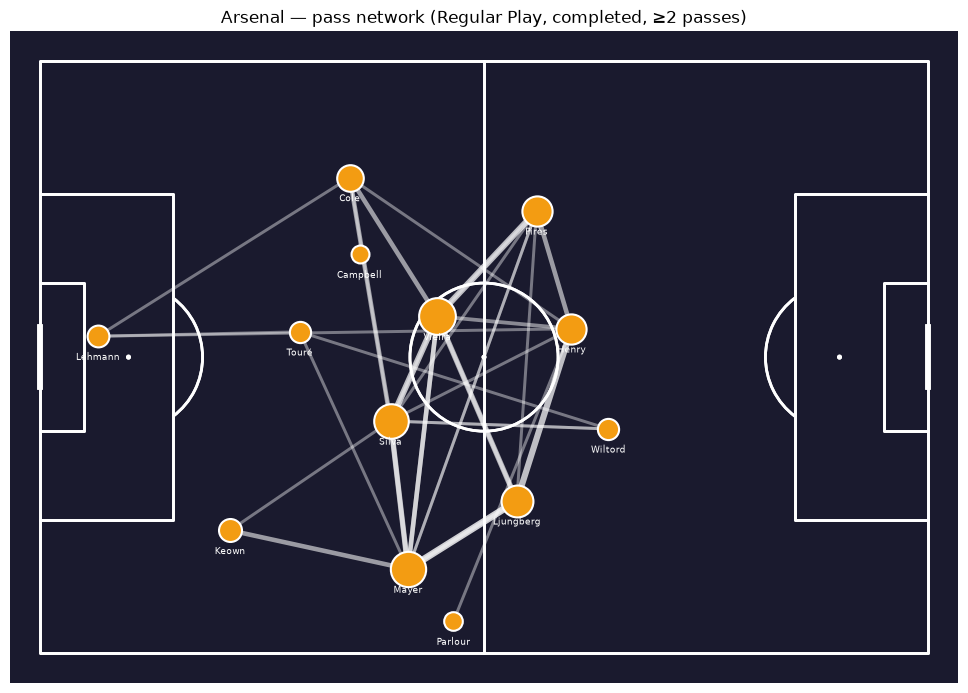


Arsenal — top 6 edges:


,player,pass_recipient,weight
0,Laureano Bisan-Etame Mayer,Fredrik Ljungberg,7
1,Patrick Vieira,Robert Pirès,6
2,Gilberto Aparecido da Silva,Patrick Vieira,6
3,Fredrik Ljungberg,Thierry Henry,6
4,Patrick Vieira,Fredrik Ljungberg,5
5,Laureano Bisan-Etame Mayer,Gilberto Aparecido da Silva,5


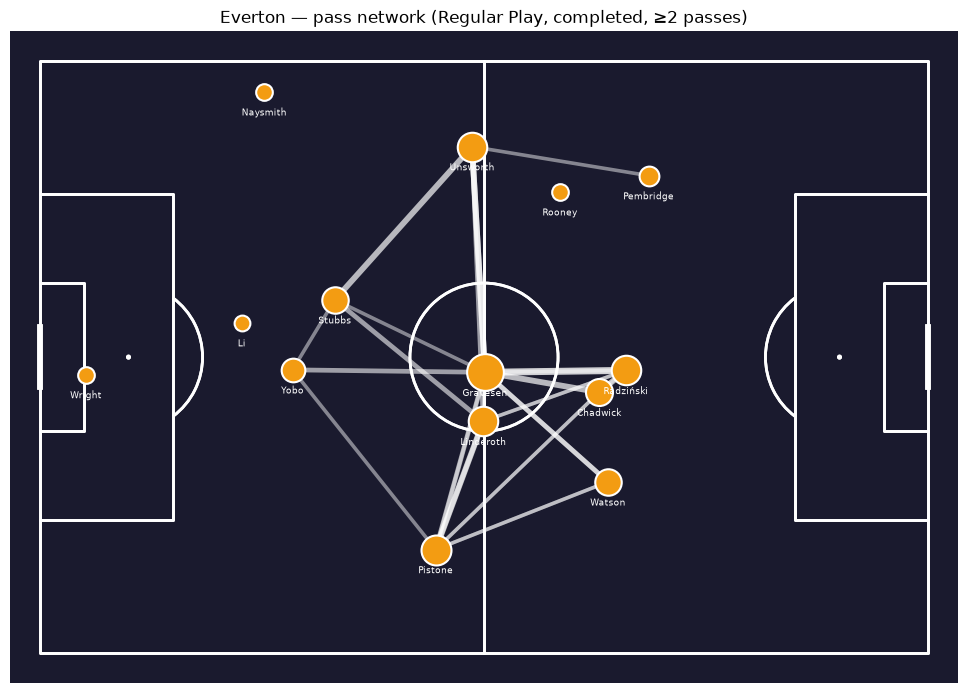


Everton — top 6 edges:


,player,pass_recipient,weight
0,Tomasz Radziński,Thomas Gravesen,5
1,Nick Chadwick,Tomasz Radziński,4
2,Thomas Gravesen,David Unsworth,4
3,David Unsworth,Alan Stubbs,4
4,David Unsworth,Thomas Gravesen,4
5,Alessandro Pistone,Tobias Linderoth,4


In [14]:
from mplsoccer import Pitch

for team in TEAMS:
    nodes, edges = build_pitch_network(match_df, team)
    pitch = Pitch(pitch_type="statsbomb", line_color="white", pitch_color="#1a1a2e")
    fig, ax = pitch.draw(figsize=(10, 7))
    plot_pitch_network(nodes, edges, team, ax=ax)
    plt.tight_layout()
    plt.show()
    print(f"\n{team} — top 6 edges:")
    display(edges.sort_values("weight", ascending=False).head(6).reset_index(drop=True))

Placing each node at its average pass origin makes the shape of each side legible. Arsenal's nodes sit higher up the pitch and their thickest links bridge the right channel (Mayer -> Ljungberg) and connect midfield to attack (Vieira -> Pirès, Ljungberg -> Henry). This suggests that Arsenal tends to cycle their possession in the midfield and circulates while in a forward position.

Everton's structure is anchored deeper and skewed toward their own half: their heaviest edges run between fullbacks, centre-backs and Gravesen (Radziński -> Gravesen, Gravesen -> Unsworth, Unsworth -> Stubbs), reflecting a side that builds and recycles closer to its own goal before committing forward.

<hr>

### Betweenness centrality — playmaker hub

**Betweenness centrality** measures how often a player sits on the shortest
passing path between any two other players. A high score means many sequences
*must route through this player* — remove them and the network fragments.

The `involvement_pct` shown alongside it is **degree-based**: it counts the
number of *distinct* teammates a player distributes to and receives from, as a
share of all such connections across the team. It captures how broadly a player
is wired into the network — the breadth of their links — not how many passes
they played.

- **High betweenness + high connectivity** -> dominant hub.
- **High betweenness + low connectivity** -> bridge / only outlet to a flank.
- **High connectivity + low betweenness** -> broadly linked but not structurally unique.


Arsenal — betweenness (top 8):


,player,betweenness,in_degree,out_degree,involvement_pct
0,Robert Pirès,0.187,8,7,10.714
1,Gilberto Aparecido da Silva,0.180,10,7,12.143
2,Thierry Henry,0.139,8,6,10.000
3,Fredrik Ljungberg,0.102,5,7,8.571
4,Martin Keown,0.100,4,5,6.429
5,Ashley Cole,0.094,5,6,7.857
6,Jens Lehmann,0.063,5,3,5.714
7,Patrick Vieira,0.062,8,8,11.429



Everton — betweenness (top 8):


,player,betweenness,in_degree,out_degree,involvement_pct
0,Joseph Phillip Yobo,0.274,3,6,7.258
1,Steve Watson,0.261,8,4,9.677
2,Tobias Linderoth,0.212,5,7,9.677
3,David Unsworth,0.116,7,5,9.677
4,Thomas Gravesen,0.093,9,7,12.903
5,Tomasz Radziński,0.092,7,6,10.484
6,Alessandro Pistone,0.085,6,6,9.677
7,Alan Stubbs,0.077,2,9,8.871


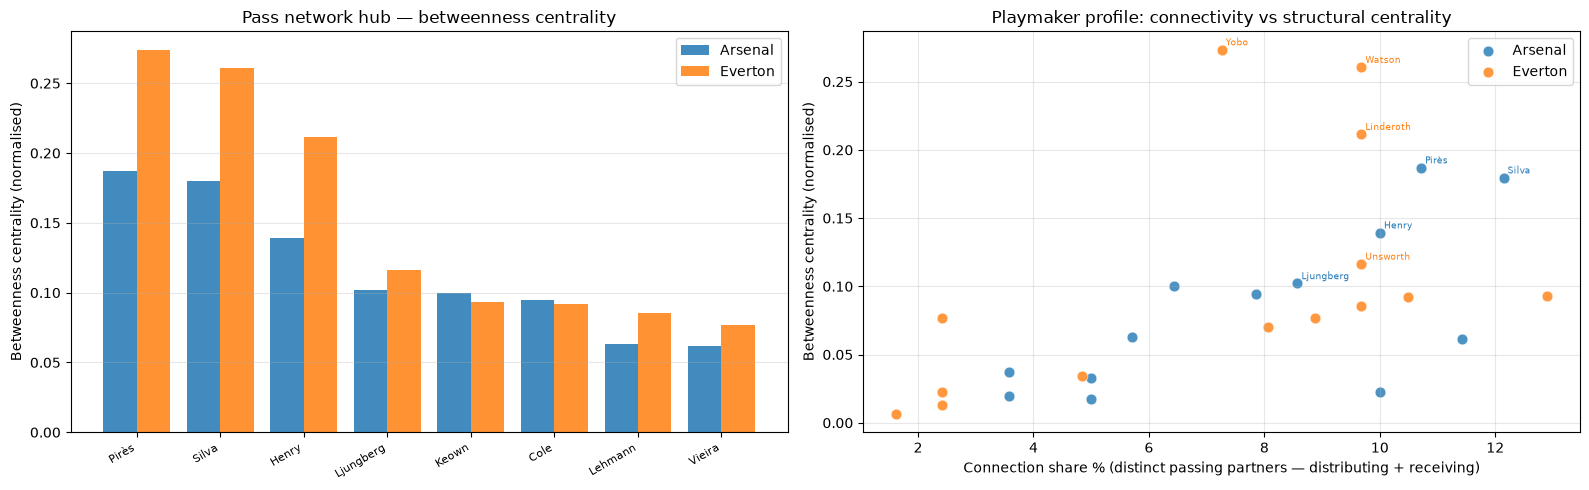

In [15]:
betweenness = {}
for team in TEAMS:
    bc = compute_betweenness_centrality(match_df, team)
    betweenness[team] = bc
    print(f"\n{team} — betweenness (top 8):")
    display(bc[["player", "betweenness", "in_degree", "out_degree", "involvement_pct"]].head(8).round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_betweenness_centrality(betweenness, top_n=8, ax=axes[0])
plot_betweenness_vs_involvement(betweenness, ax=axes[1])
plt.tight_layout()
plt.show()

**Findings — betweenness.**

- For Arsenal, the players who top betweenness are also among the most connected: Pirès (0.187 betweenness, 10.71% connection share), Gilberto (0.180, 12.14%) and Henry (0.139, 10.00%). The players wired to the most distinct teammates are also the ones sitting on the critical passing paths, so progression flows through genuinely central, broadly-linked players — a dominant-hub pattern rather than a reliance on bridges.

- Everton show the opposite split. Their highest-betweenness players are Yobo (0.274), Watson (0.261) and Linderoth (0.212), yet their most-connected player, Gravesen (12.90% connection share), ranks only fifth in betweenness at 0.093. Gravesen links with the most distinct teammates but is not structurally unique — sequences do not have to route through him — whereas Yobo and Watson act as the bridges that actually hold the network together.

- That Everton's betweenness peaks (0.27–0.21) sit well above Arsenal's (0.19–0.14) is also telling: with a sparser, less connected network there are fewer alternative routes, so individual bridge players carry more of the shortest paths and the structure is more fragile to losing them.

Conclusion: Arsenal's playmaking is concentrated in central, well-connected hubs who are both broadly linked and structurally essential. Everton's is more brittle — the player wired to the most teammates is not the one the network depends on, and their true connectors are defenders and wide midfielders bridging an otherwise loosely-linked side.

**Verdict (Section 3) — supports H1.** Taken together with the dependency and pitch-network views, Arsenal's denser, more clustered, more evenly anchored structure matches the "controlled, tactical" prediction, while Everton's sparser, bridge-reliant network matches the "more direct, less interconnected" prediction.

<hr>

## 4. Passing under pressure

**Prediction (H1).** Under pressure, the controlled side (Arsenal) should *shorten up and retain* — completion holding, forward distance dropping — while the direct side (Everton) should *go longer and more vertical* to escape.

Pressure passing separates stability from ambition. Completion under pressure shows ball security, while `pressured_mean_dx` shows whether pressured passes still moved forward. The escape structure classifies the next same-team action after a pressured pass.

,team,pressured_pass_pct,pressured_completion_pct,unpressured_completion_pct,pressured_mean_dx,unpressured_mean_dx,pressure_escape_forward_pass_pct,pressure_escape_positive_carry_pct,pressure_escape_turnover_pct
0,Arsenal,29.89,78.85,84.43,6.95,9.61,0.0,0.0,1.92
1,Everton,23.33,77.14,73.91,11.50,9.62,0.0,0.0,2.86


,team,escape_type,pct
0,Arsenal,retained_other,98.1
1,Arsenal,turnover,1.9
2,Everton,retained_other,97.1
3,Everton,turnover,2.9


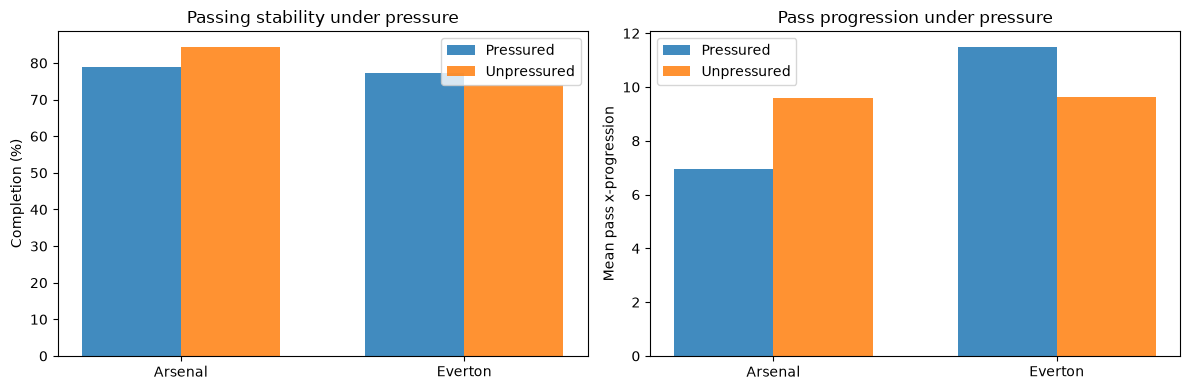

In [16]:
pressure_cols = [
    "team",
    "pressured_pass_pct",
    "pressured_completion_pct",
    "unpressured_completion_pct",
    "pressured_mean_dx",
    "unpressured_mean_dx",
    "pressure_escape_forward_pass_pct",
    "pressure_escape_positive_carry_pct",
    "pressure_escape_turnover_pct",
]
display(passing_style[pressure_cols].round(2))

escape_rows = []
for team in TEAMS:
    escapes = pressure_escape_table(match_df, team)
    if escapes.empty:
        continue
    rates = escapes["escape_type"].value_counts(normalize=True).mul(100).round(1)
    for escape_type, pct in rates.items():
        escape_rows.append({"team": team, "escape_type": escape_type, "pct": pct})
escape_summary = pd.DataFrame(escape_rows)
display(escape_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pressure_progression_split(passing_style, metric="completion", ax=axes[0])
plot_pressure_progression_split(passing_style, metric="dx", ax=axes[1])
plt.tight_layout()
plt.show()

**Findings — passing under pressure.**

- Arsenal were pressured more often (`pressured_pass_pct` 29.89% vs Everton's 23.33%), consistent with a side that holds the ball longer and invites opponents to press. Under that pressure their completion dipped from 84.43% to 78.85% — a ~5.6 point drop — and their pressured passes travelled less far forward (`pressured_mean_dx` 6.95 vs 9.61 unpressured). Arsenal stayed largely secure but became more conservative when pressed, prioritising retention over territory.
- Everton's profile is the reverse. Their completion actually *rose* under pressure (77.14% pressured vs 73.91% unpressured) and their pressured passes went *more* forward (`pressured_mean_dx` 11.50 vs 9.62). Rather than slowing down when pressed, Everton released the ball forward and faster — a long, direct outlet that beats the press rather than playing around it.
- The escape structure shows both sides were ultimately stable: ~97–98% of pressured passes were retained, with turnovers rare (Arsenal 1.9%, Everton 2.9% via `pressure_escape_turnover_pct`). Everton's marginally higher turnover rate is the natural cost of their more vertical response under pressure.

Conclusion: Both teams handled pressure without significant ball loss, but they composed themselves differently. Arsenal invites and absorbs pressure, creating space and trading forward yards for security. Everton answered pressure by going longer, more direct and more rushed at times, accepting a slightly higher turnover risk to escape upfield.

**Verdict — supports H1.** This is one of the cleanest tests: the two sides responded to pressure in exactly the opposite ways the hypothesis predicts — Arsenal shortened up and retained, Everton went longer and more vertical.

<hr>

## 5. Progression mechanism

**Prediction (H1).** Arsenal should rely *relatively more on carries* to advance, with smaller per-action gains; Everton should rely on passing — and especially the long ball — for larger per-pass territorial gains.

This compares whether open-play progression came through passes or carries. `positive_pass_progression` and `positive_carry_progression` sum only forward x-gains, so the shares describe the mechanism used to advance the ball rather than total activity volume.

,team,positive_pass_progression,positive_carry_progression,pass_progression_share_pct,carry_progression_share_pct,progression_per_pass,progression_per_carry,progressive_pass_pct,progressive_carry_pct
0,Arsenal,1968.1,661.0,74.86,25.14,8.82,3.19,41.38,15.24
1,Everton,1865.5,447.0,80.67,19.33,10.06,2.78,40.00,11.76


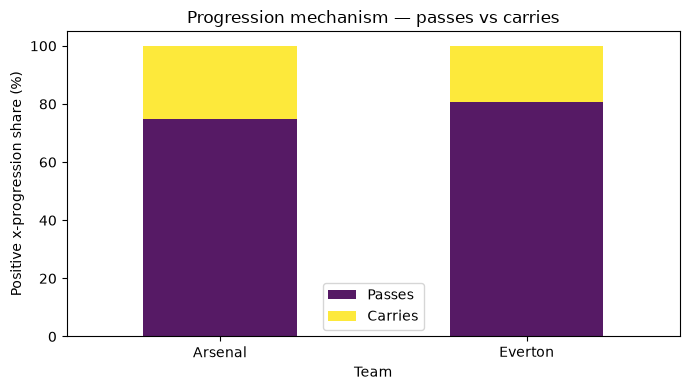

In [17]:
progression_cols = [
    "team",
    "positive_pass_progression",
    "positive_carry_progression",
    "pass_progression_share_pct",
    "carry_progression_share_pct",
    "progression_per_pass",
    "progression_per_carry",
    "progressive_pass_pct",
    "progressive_carry_pct",
]
display(passing_style[progression_cols].round(2))

fig, ax = plt.subplots(figsize=(7, 4))
plot_pass_vs_carry_progression(passing_style, ax=ax)
plt.tight_layout()
plt.show()

**Findings — progression mechanism.** Looking at how each team progresses up the pitch, both Arsenal and Everton rely primarily on passing — but Arsenal leans on carries noticeably more, with a 74.86% / 25.14% pass-to-carry split against Everton's more pass-heavy 80.67% / 19.33%. The two also differ in how much ground each action covers: Everton gains more per pass (10.06 vs 8.82), while Arsenal advances further per carry (3.19 vs 2.78). Crucially, Arsenal is also more efficient at turning actions into progression, with a higher share of both progressive passes (41.38% vs 40.00%) and progressive carries (15.24% vs 11.76%).

In conclusion, while both sides build through passing, Arsenal relies on carries more than Everton to progress up the field, and converts a higher proportion of its passes and carries into genuine forward progress.

**Verdict — supports H1 (with a wording caveat).** The relative pattern matches the prediction — Arsenal more carry-led, Everton more pass/long-ball-led with larger per-pass gains. The caveat is that *both* teams are pass-dominant overall; "Arsenal prefers carries" is true only *relative to* Everton, not in absolute terms.

<hr>

## 6. Discussion and conclusion

**Does the evidence support H1?** Across five independent metric families, this fixture is broadly consistent with the hypothesised stylistic contrast — with one important refinement.

**Where H1 holds clearly**

- *Length & build-up (S1–S2).* Arsenal passed shorter (e.g. 22.3 vs 25.5 yards in the defensive third) and retained the ball in their own half; Everton played longer and exited the defensive third faster and more directly (100% exit rate, 76.9% direct exits vs Arsenal's 83.3% / 56.0%). This is the clearest support for "Arsenal measured, Everton long-ball and rushed."
- *Networks (S3).* Arsenal's higher connectivity (0.45 vs 0.34) and clustering (0.75 vs 0.62), with hubs that are both well-connected and structurally central, fit the controlled, tactical reading. Everton's sparser, bridge-dependent network is the more fragile structure.
- *Pressure (S4).* Under pressure Arsenal shortened up (forward distance 6.95 vs 9.61 unpressured) and prioritised retention; Everton went *longer and more vertical* (11.50 vs 9.62) — a textbook escape-via-the-long-ball response.
- *Progression (S5).* Arsenal leaned on carries more than Everton (25.1% vs 19.3% of progression) and converted a higher share of both passes and carries into forward progress; Everton gained more ground per pass (10.06 vs 8.82), the long-ball signature.

**Where H1 needs refinement**

- The "Everton = direct/forward" intuition is only half right. At the level of individual pass *direction*, Everton was actually *less* forward and *more* backward/lateral than Arsenal (forward 59.3% vs 66.1%), and their forward share collapsed in the final third (27.6%). Everton's directness lives in pass *length* and *speed of transition out of defense*, not in a more forward-facing orientation on every pass. Arsenal — the slower, more controlled side — was paradoxically the more consistently forward-oriented in possession.
- "Arsenal prefers carries" is true only *relative to Everton*. Both teams progressed primarily by passing; Arsenal simply carried more than their opponent did.

**Conclusion.** For this fixture, **H1 is supported with qualification.** Arsenal were the more controlled, connected, short-passing, carry-leaning side that built patiently from the back; Everton were the longer, faster-transitioning, more bridge-dependent side that escaped pressure vertically. The key nuance is that "direct" is best understood as *long and fast in transition* rather than *more forward in orientation* — by the latter measure, Arsenal were actually the more vertical team.

**Limitations.** This is a single-match case study (Arsenal 2–1 Everton, 16 Aug 2003), so the results illustrate rather than prove a season-long tendency. Per-zone sample sizes are small (e.g. only 13 Everton defensive-third possessions), score-state and opponent effects are uncontrolled, and these metrics describe *style*, not quality or outcome. Replicating this profile across a full season — and controlling for game state — is the natural next step.